In [2]:
import sys 
sys.path.append('../') 
from mlwpy import *
%matplotlib inline

In [11]:
#comparing various learners
results=[]
loo = skms.LeaveOneOut()
folds = {
    'Leave-One-Out':skms.LeaveOneOut(),
    'Kfold(2)':skms.KFold(2),
    'KFold(3)':skms.KFold(3),
    'KFold(5)':skms.KFold(5),
    'KFold(10)':skms.KFold(10)
}

linreg = linear_model.LinearRegression()
iris = datasets.load_iris()
for name,cv_methods in folds.items():
    scores = skms.cross_val_score(linreg,iris.data,iris.target,cv=cv_methods,scoring= 'neg_mean_squared_error',n_jobs=-1)
    results.append({'Fold':name,'RMSE':np.sqrt(-scores)})




print(results)




[{'Fold': 'Leave-One-Out', 'RMSE': array([0.0843, 0.0412, 0.0497, 0.0126, 0.0772, 0.0603, 0.0394, 0.0453,
       0.0204, 0.0841, 0.1043, 0.0008, 0.0921, 0.1058, 0.2425, 0.0442,
       0.0347, 0.0221, 0.0334, 0.0111, 0.0446, 0.0556, 0.126 , 0.1808,
       0.0724, 0.0057, 0.1021, 0.0724, 0.0919, 0.0204, 0.013 , 0.0339,
       0.1663, 0.1644, 0.0217, 0.1083, 0.1568, 0.1289, 0.0072, 0.0568,
       0.0341, 0.0772, 0.0155, 0.2252, 0.147 , 0.0329, 0.0507, 0.0149,
       0.0926, 0.0646, 0.2102, 0.288 , 0.3333, 0.1914, 0.319 , 0.265 ,
       0.4048, 0.0977, 0.18  , 0.248 , 0.0464, 0.2829, 0.0523, 0.3207,
       0.0596, 0.1759, 0.3942, 0.0248, 0.368 , 0.022 , 0.6096, 0.0998,
       0.4252, 0.2049, 0.1316, 0.1909, 0.2733, 0.5036, 0.3446, 0.1492,
       0.0142, 0.0719, 0.0527, 0.561 , 0.4253, 0.3925, 0.3067, 0.1974,
       0.1721, 0.1811, 0.2124, 0.2926, 0.0802, 0.1054, 0.2074, 0.1228,
       0.1875, 0.1533, 0.1335, 0.1677, 0.2617, 0.2539, 0.1022, 0.2658,
       0.0055, 0.0045, 0.4295, 0.2223, 0.2

In [13]:
df  = pd.DataFrame({
    'Folds': [item['Fold'] for item in results],
    'Mean RMSE':[item['RMSE'].mean() for item in results]
})

display(df)


,Folds,Mean RMSE
0,Leave-One-Out,0.1709
1,Kfold(2),0.5204
2,KFold(3),0.5917
3,KFold(5),0.2444
4,KFold(10),0.2225


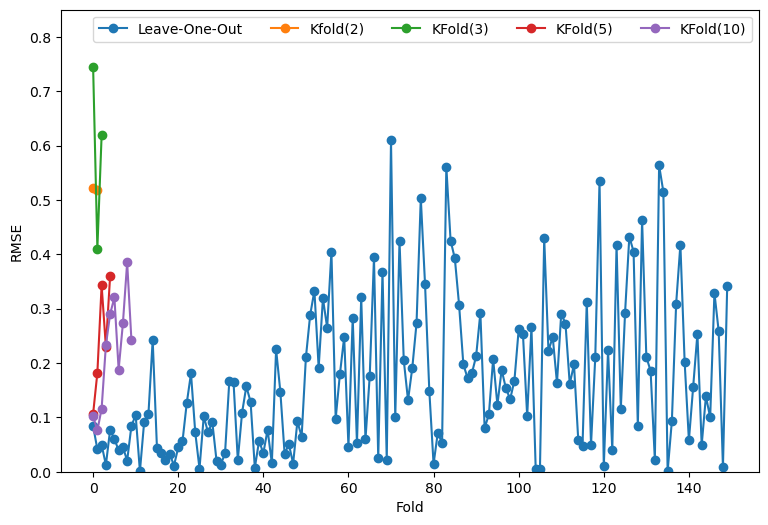

In [33]:
fig,ax = plt.subplots(figsize=(9,6))

for result in results:
    fold = result['Fold']
    rmse = result['RMSE']
    ax.plot(rmse,'-o',label=fold)

ax.set_ylim(0,0.85)
ax.set_xlabel('Fold')
ax.set_ylabel('RMSE')
ax.legend(ncol=5)

    
    



55.2
67.0
53.85
67.0
54.333333333333336
67.0
53.85
67.0
52.44
66.0
[67, 77, 67, 67, 13, 67, 67, 67, 30, 30, 97, 30, 25, 4, 67, 25, 66, 67, 77, 67, 85, 67, 42, 100, 4, 67, 30, 66, 25, 67, 85, 45, 85, 30, 13, 45, 3, 85, 100, 33, 100, 17, 33, 33, 33, 67, 45, 85, 30, 25]


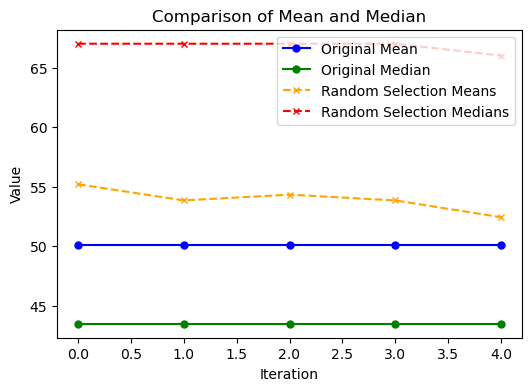

In [104]:
#2 compare means of various iterations
import random
integers = [random.randint(1,100) for _ in range(20)]
integers_mean = np.mean(integers)
integers_median = np.median(integers)
selection1_means = []
selection1_medians =[]
selection_1 = []
print('\n')

for _ in range(5):
        for _ in range(10):
            random_index = random.randint(1,19)
            selection_1.append(integers[random_index])
     
     
        mean = np.mean(selection_1)
        median = np.median(selection_1)
        selection1_means.append(mean)
        selection1_medians.append(median)
    
        print(mean)
        print(median)
print(selection_1)
integers

# Prepare a DataFrame to display the results
data = {
    "Original Mean": [integers_mean]*5,
    "Original Median": [integers_median]*5,
    "Random Selection Means": selection1_means,
    "Random Selection Medians": selection1_medians
}

# Create a pandas DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
df

# Plotting
fig, ax = plt.subplots(figsize=(6, 4))

# Plot each column of the DataFrame
ax.plot(df.index, df['Original Mean'], label='Original Mean', color='blue', marker='o', linestyle='-', markersize=5)
ax.plot(df.index, df['Original Median'], label='Original Median', color='green', marker='o', linestyle='-', markersize=5)
ax.plot(df.index, df['Random Selection Means'], label='Random Selection Means', color='orange', marker='x', linestyle='--', markersize=5)
ax.plot(df.index, df['Random Selection Medians'], label='Random Selection Medians', color='red', marker='x', linestyle='--', markersize=5)

# Set the labels and title
ax.set_xlabel('Iteration')
ax.set_ylabel('Value')
ax.set_title('Comparison of Mean and Median')

# Display legend
ax.legend()
